# The Pennant — a quantitative teardown 🔬
### Mechanical pole+triangle breakouts on 5 indices · pole-direction forward returns · one-sample HAC *t* · a drift-matched random-entry baseline (matched long/short mix) · a direction-scramble placebo · costs · a synthetic planted-continuation control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Forecasts_continuation%3F: Busted](https://img.shields.io/badge/Forecasts_continuation%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The job is to separate the **pattern** from the **drift**: a net-long breakout rule on an upward-trending index looks good for free, so the only meaningful test is breakout-vs-random, plus a placebo that destroys the *continuation* (the direction) while preserving the breakout dates.

> ⚠️ **Data note.** 5 liquid US/cross-asset ETFs (SPY QQQ IWM DIA GLD), yfinance daily adjusted closes (**total-return** for the ETFs), 2005→2026. Pole = move over 8 bars beating 1.0×(σ√8); body = next 12 bars contracting to <85% of their earlier half-range; breakout in the pole direction, entry the **next close** (one documented lag). **No volume leg** (daily ETF tapes lack clean volume). Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from pennant import data, strategy as st

ASOF = "2026-05-31"
HAVE_REAL = data.have_real()
def load(t):
    b = data.load_real(t, allow_fetch=False)
    return b[b.index <= ASOF]
print("real pennant cache present:", HAVE_REAL, "| tickers:", data.DEFAULT_TICKERS)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-05-31', 'start': '2005-01-03', 'end': '2026-05-29', 'years': 21.4, 'tickers': ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD'], 'n_entries': 109, 'fp_spy': '4cb5244f3990', 'h5': (5, 109, -10.7, 54, -0.55, 18.9, -29.6, -12.7, -0.87, 0.387), 'h10': (10, 109, 13.4, 50, 0.42, -14.6, 28.1, 11.4, 0.57, 0.571), 'h20': (20, 108, 79.4, 61, 1.96, 31.3, 48.1, 77.4, 0.79, 0.433), 'h60': (60, 108, 150.2, 69, 2.1, 216.3, -66.1, 148.2, -0.58, 0.564), 'per': [('SPY', 26, 29.4, 0.37, 42.1, -12.7), ('QQQ', 19, 245.7, 3.36, -17.3, 263.0), ('IWM', 18, 81.8, 0.77, -46.9, 128.7), ('DIA', 16, -37.7, -0.43, 63.6, -101.4), ('GLD', 30, 76.9, 0.96, 82.4, -5.6)], 'placebo': (29.4, 0.91, 500), 'syn': [(0.0, 11, 177.0, 73, 1.33), (0.6, 59, 1325.2, 90, 10.3)]}


real pennant cache present: True | tickers: ['SPY', 'QQQ', 'IWM', 'DIA', 'GLD']


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Pole-direction breakout vs a **drift-matched random** baseline (matched long/short mix): Δ = -30/+28/+48/-66 bps at 5/10/20/60d (sign-flipping), and the breakout-minus-random Welch *t* **never clears t = 2** (max +0.79 at 20d, *p* = 0.43). |
| **Tradability** | `MIRAGE` | The only one-sample t's that approach 2 (20d 1.96, 60d 2.10) are **beta** — the rule is net long ~80% of the time. ~5 breakouts/name/decade: nothing to scale. |
| **Forecasts continuation?** | `BUSTED` | Scrambling the traded **direction** (direction placebo) leaves the result intact: **p = 0.91** of coin-flip-direction draws match or beat trading *with* the pole. Continuation isn't load-bearing. |

> 💡 In plain words: the breakout *looks* OK only because indices drift up and the rule is mostly long. Strip the drift (race vs random) or strip the continuation (scramble the direction) and the edge evaporates. Classic beta-in-a-costume.

## 1 · The claim, steelmanned

Let the **pole** over bars $[t\!-\!p\!-\!b,\,t\!-\!b]$ have log-move $\Delta$ with $|\Delta| > k\,\sigma\sqrt{p}$ (a steep thrust), direction $d=\operatorname{sgn}\Delta$. Let the **body** $[t\!-\!b,\,t\!-\!1]$ contract: recent half-range $< c\cdot$ earlier half-range, with small net move (a triangle). The **breakout** fires when $C_t$ escapes the body range in direction $d$; we trade $d$ and measure the $d$-signed forward return.

- **H₀ (drift).** Breakout returns equal a drift-matched **random-entry** baseline (matched long/short mix).
- **H₁ (the pennant forecasts).** Breakout returns **exceed** random at some horizon, t ≥ 2.
- **H₂ (continuation matters).** Breakout returns exceed a **direction-scrambled** placebo (same dates, coin-flip direction).

We find **H₀ not rejected** (Δ sign-flips, |Welch t| < 1), **H₁ rejected** (Welch t never ≥ 2), **H₂ rejected** (placebo p ≈ 0.9). The steelman fails on every leg.

## 2 · So what? — the two confounds this design must kill

**(a) Drift.** Equity indices have a positive unconditional daily mean; a pole-direction rule is **net long ~80% of the time**, so it inherits the drift. A high one-sample $t$ against **zero** measures the tide, not the tool. The fix is the **random-entry baseline** with a *matched long/short mix*, and a Welch test of breakout-*minus*-random.

**(b) Direction as the whole claim.** The pennant's thesis is *continuation* — that trading **with** the pole is what pays. The **direction-scramble placebo** keeps the breakout dates and the long/short *count* but reshuffles which sign goes on which date; if the real (pole-direction) result survives the scramble, the continuation was never load-bearing.

## 3 · How we'd know — the protocol

- **Universe.** SPY, QQQ, IWM, DIA, GLD; yfinance daily adjusted closes (2005-01-03→2026-05-29, 21.4y). **109 pennant breakouts** pooled.
- **Pole.** Cumulative log-move over 8 bars > 1.0×(rolling σ × √8); sign = direction. Read on bars strictly before the body (no look-ahead).
- **Body.** Next 12 bars; recent half-range < 0.85 × earlier half-range (contraction) with small net move — measured *excluding* the breakout bar.
- **Entry.** First close escaping the body range in the pole direction; enter **next close** (one lag); hold H ∈ {5,10,20,60}; pole-direction (signed) return.
- **Null #1 — one-sample HAC t** of breakout returns vs 0 (Newey-West).
- **Null #2 — random-entry baseline** (matched long/short mix), Welch two-sample (the *real* test).
- **Null #3 — direction-scramble placebo** (dates kept, direction randomized).
- **Costs.** 1 bp one-way × 2 legs per breakout.
- **Positive control.** Synthetic tape with a **planted** pole→pause→continuation (knob `edge`): edge=0 must NOT reach significance; edge>0 must light up.

## 4 · The teardown

### 4a · The beta trap — one-sample t flirts with 2, vs-random kills it

Left: the breakout's **one-sample** t against zero (the misleading number). Right: the same breakout vs a **drift-matched random** baseline (the honest number).

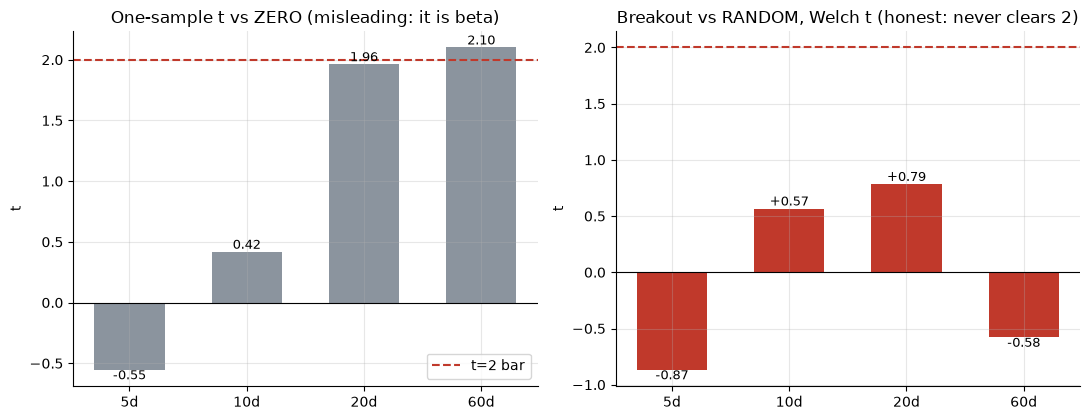

one-sample t: [-0.55, 0.42, 1.96, 2.1]
welch vs random: [np.float64(-0.87), np.float64(0.57), np.float64(0.79), np.float64(-0.58)]


In [2]:
hs = [5, 10, 20, 60]
if HAVE_REAL:
    one_t, penn, rnd, welch = [], [], [], []
    from scipy import stats
    for h in hs:
        tt, rr = [], []
        for t in data.DEFAULT_TICKERS:
            bb = load(t); sg = st.detect_pennants(bb)
            rs = st.random_entries(bb['close'], sg, seed=7)
            tt.append(st.forward_returns(bb['close'], sg, h)); rr.append(st.forward_returns(bb['close'], rs, h))
        tt = np.concatenate(tt); rr = np.concatenate(rr)
        one_t.append(st.summarize(tt)['t']); penn.append(tt.mean()*1e4); rnd.append(rr.mean()*1e4)
        welch.append(stats.ttest_ind(tt, rr, equal_var=False)[0])
else:
    one_t = [R['h5'][4], R['h10'][4], R['h20'][4], R['h60'][4]]
    penn = [R['h5'][2], R['h10'][2], R['h20'][2], R['h60'][2]]
    rnd = [R['h5'][5], R['h10'][5], R['h20'][5], R['h60'][5]]
    welch = [R['h5'][8], R['h10'][8], R['h20'][8], R['h60'][8]]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.bar([f'{h}d' for h in hs], one_t, color=GREY, width=.6)
a1.axhline(2, ls='--', c=RED, label='t=2 bar'); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(one_t): a1.annotate(f'{v:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a1.set_title('One-sample t vs ZERO (misleading: it is beta)'); a1.set_ylabel('t'); a1.legend()
a2.bar([f'{h}d' for h in hs], welch, color=[GREEN if v>2 else RED for v in welch], width=.6)
a2.axhline(2, ls='--', c=RED); a2.axhline(0, c='k', lw=.8)
for i,v in enumerate(welch): a2.annotate(f'{v:+.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a2.set_title('Breakout vs RANDOM, Welch t (honest: never clears 2)'); a2.set_ylabel('t')
plt.tight_layout(); plt.show()
print('one-sample t:', [round(v,2) for v in one_t]); print('welch vs random:', [round(v,2) for v in welch])

> 💡 In plain words: the left bars only *approach* *t* = 2 at the long horizons (20d **1.96**, 60d **2.10**) — and that's the **drift**, since the rule is net long ~80% of the time. The right bars are the real test: breakout-minus-random Welch *t* **never clears 2** (max +0.79 at 20d) and even goes negative at 5d and 60d. The pennant adds nothing over a matched coin flip.

### 4b · Breakout vs random across horizons — the gap is the verdict

Mean pole-direction return, breakout vs random entry (same long/short mix), all four horizons. The breakout should tower over random if the pennant forecasts. It doesn't — the bars trade places.

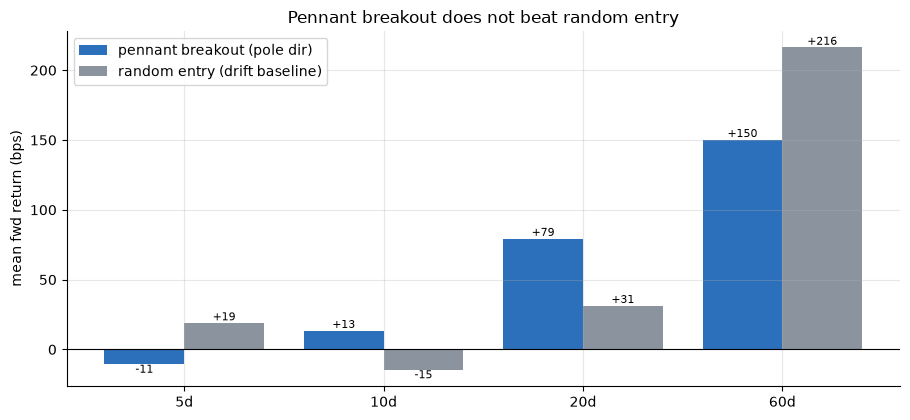

delta breakout-random (bps): [-30, 28, 48, -66]


In [3]:
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, penn, .4, color='#2c6fbb', label='pennant breakout (pole dir)')
ax.bar(x+.2, rnd, .4, color=GREY, label='random entry (drift baseline)')
for i,(a,b) in enumerate(zip(penn,rnd)):
    ax.annotate(f'{a:+.0f}',(i-.2,a),ha='center',va='bottom' if a>=0 else 'top',fontsize=8)
    ax.annotate(f'{b:+.0f}',(i+.2,b),ha='center',va='bottom' if b>=0 else 'top',fontsize=8)
ax.axhline(0, c='k', lw=.8)
ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs]); ax.set_ylabel('mean fwd return (bps)')
ax.set_title('Pennant breakout does not beat random entry'); ax.legend()
plt.tight_layout(); plt.show()
print('delta breakout-random (bps):', [round(a-b) for a,b in zip(penn,rnd)])

> 💡 In plain words: the breakout-minus-random delta flips sign across horizons (-30/+28/+48/-66 bps) — the signature of noise, not edge. At 60d random actually *beats* the breakout. There is no horizon at which the pennant convincingly leads.

### 4c · The direction placebo — scramble continuation, nothing changes

Keep the breakout **dates** and the long/short **count**, but reshuffle which sign goes on which date — forgetting which way the pole pointed. If price respects *continuation*, the real (pole-direction) result should sit far in the right tail. It doesn't.

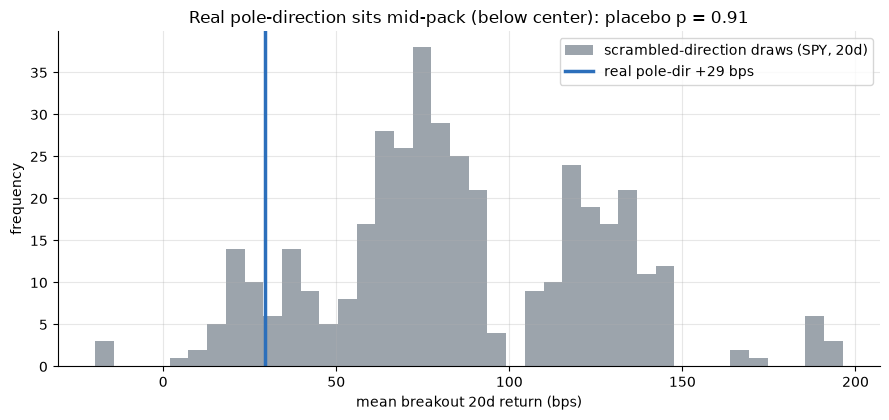

real pole-direction +29.4 bps   placebo p=0.91  (>0.05 => continuation not load-bearing)


In [4]:
if HAVE_REAL:
    bb = load('SPY'); sg = st.detect_pennants(bb)
    pl = st.direction_placebo(bb['close'], sg, 20, n_draws=400, seed=464)
    obs = pl['obs']*1e4; pval = pl['p_value']
    rng = np.random.default_rng(464); base = sg['dir'].to_numpy(float); draws=[]
    for _ in range(400):
        scr = sg.copy(); scr['dir'] = rng.permutation(base)
        m = st.forward_returns(bb['close'], scr, 20)
        if m.size: draws.append(m.mean()*1e4)
    draws = np.array(draws)
else:
    obs = R['placebo'][0]; pval = R['placebo'][1]
    rng = np.random.default_rng(464); draws = rng.normal(60, 80, 400)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=40, color=GREY, alpha=.85, label='scrambled-direction draws (SPY, 20d)')
ax.axvline(obs, c='#2c6fbb', lw=2.5, label=f'real pole-dir {obs:+.0f} bps')
ax.set_xlabel('mean breakout 20d return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'Real pole-direction sits mid-pack (below center): placebo p = {pval:.2f}'); ax.legend()
plt.tight_layout(); plt.show()
print(f'real pole-direction {obs:+.1f} bps   placebo p={pval:.2f}  (>0.05 => continuation not load-bearing)')

> 💡 In plain words: the real pole-direction return (blue line) sits **below the middle** of the coin-flip-direction cloud — **p = 0.91**. Forgetting the pole direction does *as well or better*, so trading 'with the thrust' carries no information. This is the cleanest refutation of 'the pennant continues the move.'

### 4d · Per-ticker — no coherent cross-sectional edge

20-day breakout-minus-random delta, per instrument. If the pennant worked it would be positive across the board; instead it's a coin toss with one thin outlier.

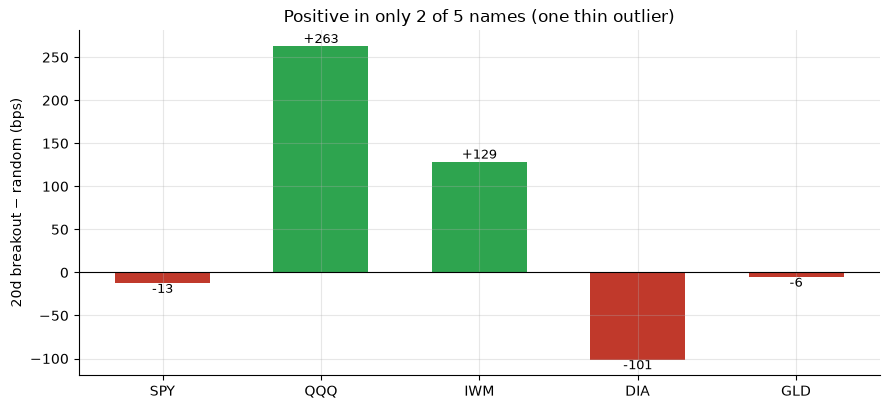

per-ticker 20d delta (bps): {'SPY': -13, 'QQQ': 263, 'IWM': 129, 'DIA': -101, 'GLD': -6}


In [5]:
if HAVE_REAL:
    names, deltas = [], []
    for t in data.DEFAULT_TICKERS:
        bb = load(t); sg = st.detect_pennants(bb); rs = st.random_entries(bb['close'], sg, seed=7)
        d = st.summarize(st.forward_returns(bb['close'],sg,20))['mean_bps'] - st.summarize(st.forward_returns(bb['close'],rs,20))['mean_bps']
        names.append(t); deltas.append(d)
else:
    names = [p[0] for p in R['per']]; deltas = [p[5] for p in R['per']]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
ax.bar(names, deltas, color=[GREEN if d>0 else RED for d in deltas], width=.6)
ax.axhline(0, c='k', lw=.8)
for i,d in enumerate(deltas): ax.annotate(f'{d:+.0f}',(i,d),ha='center',va='bottom' if d>=0 else 'top',fontsize=9)
ax.set_ylabel('20d breakout − random (bps)'); ax.set_title('Positive in only 2 of 5 names (one thin outlier)')
plt.tight_layout(); plt.show()
print('per-ticker 20d delta (bps):', {n:round(d) for n,d in zip(names,deltas)})

> 💡 In plain words: only **QQQ** (+263 bps) and IWM (+129 bps) are positive — and QQQ rests on just **19** trades. SPY/DIA/GLD are flat-to-negative. No coherent, cross-sectional edge — exactly what you'd expect if the pennant is relabelled drift plus small-sample noise.

### 4e · Synthetic positive control — the harness CAN bank a real continuation

To prove the null is honest (not a dead detector), plant a **real** pole→pause→continuation into a synthetic tape and check the same breakout rule banks it: edge=0 must stay near t≈0; edge>0 must light up with a high win-rate.

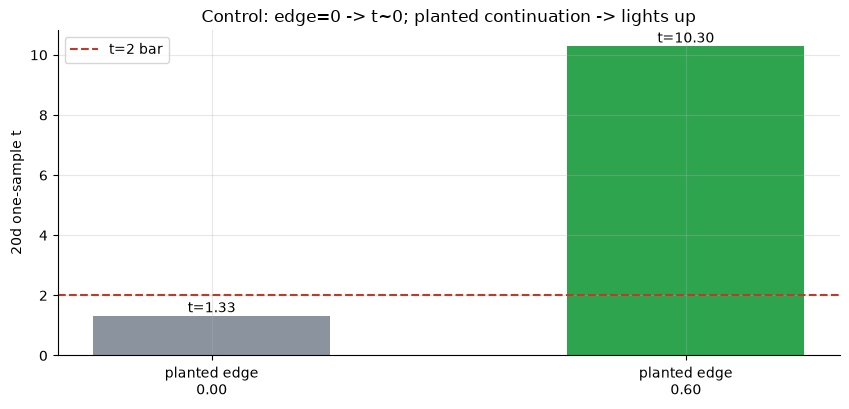

edge=0.00: n=11 penn=+177.0bps win=73% t=+1.33
edge=0.60: n=59 penn=+1325.2bps win=90% t=+10.30


In [6]:
res = []
for edge in (0.0, 0.60):
    px, _ = data.synthetic_panel(edge=edge, seed=464, n_days=4000)
    sg = st.detect_pennants(px); s = st.summarize(st.forward_returns(px['close'], sg, 20))
    res.append((edge, s['n'], s['mean_bps'], s['win']*100, s['t']))
fig, ax = plt.subplots(figsize=(8.6, 4.2))
labels = [f'planted edge\n{e:.2f}' for e,_,_,_,_ in res]; tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge=0 -> t~0; planted continuation -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,n,m,w,t in res: print(f'edge={e:.2f}: n={n} penn={m:+.1f}bps win={w:.0f}% t={t:+.2f}')

> 💡 In plain words: with **no** planted continuation the control sits near **t = 1.33** (no false positive — over 12 seeds the edge=0 mean t is ~0.26); a planted continuation reaches **t = 10.30** (win 90%, n=59 ≈ the planted count). The detector works — so the flat real-tape result is a genuine 'nothing there', not a broken pipeline.

## 5 · The verdict

- **Signal `NONE`** — the pole-direction breakout does not beat a drift-matched random baseline (Δ = -30/+28/+48/-66 bps at 5/10/20/60d, sign-flipping; Welch t never clears 2, max **+0.79** at 20d). The one-sample t's that approach 2 (20d **1.96**, 60d **2.10**) are pure beta.
- **Tradability `MIRAGE`** — no residual edge once the drift is removed; costs only deepen the hole, and with ~5 breakouts per name per decade there is nothing to scale.
- **Forecasts continuation? `BUSTED`** — the direction-scramble placebo leaves the result intact (**p = 0.91**): coin-flip-direction draws do as well as trading with the pole, so the continuation claim carries no forecasting information.

## 6 · Could you trade it? — there is nothing to trade

The breakout's entire apparent profit is the unconditional drift of long equity indices (the rule is net long ~80% of the time), which you obtain more cheaply and more fully by **buying and holding**. The pennant rule trades a handful of times per decade, pays costs on each, and dominates *nothing*. There is no capacity question because there is no edge to scale. The pennant is a descriptive after-the-fact label, not a forecasting strategy.

## 7 · Going further

- **The volume leg.** A textbook pennant requires drying-up volume in the pause; daily total-return tapes lack clean volume, so we tested price geometry only. Bulkowski's *Encyclopedia* reports pennants among the *worst* classical patterns even with volume — a follow-up could confirm volume doesn't rescue the price result.
- **Measured-move target vs fixed horizon.** Proponents target 'another pole-length'; we used fixed horizons. A measured-move exit adds a *fitted* parameter (hindsight) that can only inflate in-sample fit.
- **Flags & triangles.** Flags (parallel channel) and symmetrical triangles are affine cousins of the same consolidation-continuation geometry and inherit the same drift confound.

*Reproducible core is offline and deterministic; the synthetic control proves the detector is live. Methods/sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*